In [58]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 데이터 불러오기
df = pd.read_csv('WA_Marketing-Campaign.csv')

# 1. 행 수, 컬럼 수
print("=== 데이터 크기 ===")
print(f"행 수: {df.shape[0]}, 열 수: {df.shape[1]}")

# 2. 컬럼별 자료형 확인
print("\n=== 컬럼별 자료형 ===")
print(df.dtypes)

# 3. 데이터 미리보기
print("\n=== 상위 5행 ===")
print(df.head())

# 4. 결측치 확인 (컬럼별 개수 + 비율)
print("\n=== 결측치 개수 ===")
print(df.isnull().sum())

print("\n=== 결측치 비율(%) ===")
print((df.isnull().sum() / len(df) * 100).round(2))

# 5. 기초 통계량 (수치형 컬럼)
print("\n=== 기초 통계량 ===")
print(df.describe())

# 6. 범주형 컬럼 고유값 확인 (Promotion, MarketSize, week 등)
print("\n=== 범주형/이산형 컬럼 고유값 ===")
for col in ['MarketID', 'MarketSize', 'Promotion', 'week']:
    print(f"\n{col}: {df[col].unique()}")
    print(df[col].value_counts().sort_index())
    
# 7. 완전 중복 행 개수 확인    
print("=== 완전 중복 행 개수 ===")
print(df.duplicated().sum())

=== 데이터 크기 ===
행 수: 548, 열 수: 7

=== 컬럼별 자료형 ===
MarketID              int64
MarketSize              str
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

=== 상위 5행 ===
   MarketID MarketSize  LocationID  AgeOfStore  Promotion  week  \
0         1     Medium           1           4          3     1   
1         1     Medium           1           4          3     2   
2         1     Medium           1           4          3     3   
3         1     Medium           1           4          3     4   
4         1     Medium           2           5          2     1   

   SalesInThousands  
0             33.73  
1             35.67  
2             29.03  
3             39.25  
4             27.81  

=== 결측치 개수 ===
MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

=== 결측치

In [59]:
# ===== 1. Promotion 타입 변환 =====
df['Promotion'] = df['Promotion'].astype('category')
print("=== 변환 후 자료형 ===")
print(df.dtypes)

# ===== 2. 완전 중복 행 체크 =====
print("\n=== 완전 중복 행 개수 ===")
print(df.duplicated().sum())

# ===== 3. LocationID + week 조합 중복 체크 =====
print("\n=== LocationID + week 조합 중복 체크 ===")
dup_key = df.duplicated(subset=['LocationID', 'week'], keep=False)
print(f"중복 조합 개수: {dup_key.sum()}")
if dup_key.sum() > 0:
    print(df[dup_key].sort_values(['LocationID', 'week']))

# ===== 4. 배정 일관성 체크 (한 매장 = 한 Promotion이어야 함) =====
print("\n=== LocationID당 Promotion 종류 수 ===")
promo_per_location = df.groupby('LocationID')['Promotion'].nunique()
inconsistent = promo_per_location[promo_per_location > 1]
print(f"하나의 매장이 여러 프로모션에 배정된 경우: {len(inconsistent)}건")
if len(inconsistent) > 0:
    print(inconsistent)

# ===== 5. 매장당 관측 주차 수 체크 (원래 4주씩 있어야 함) =====
print("\n=== LocationID당 관측된 주차 수 분포 ===")
weeks_per_location = df.groupby('LocationID')['week'].nunique()
print(weeks_per_location.value_counts())
incomplete = weeks_per_location[weeks_per_location != 4]
if len(incomplete) > 0:
    print(f"\n4주 미만/초과로 기록된 매장: {len(incomplete)}건")
    print(incomplete)

# ===== 6. LocationID당 여러 시장에 중복되어있는지 확인 ======
print("\n=== LocationID당 여러 시장에 분포되었는지 확인 ===")
market_per_location = df.groupby('LocationID')['MarketID'].nunique()
print((market_per_location > 1).sum(), "건")

# ===== 정제 전후 행 수 기록용 =====
rows_before = len(df)
print(f"\n=== 현재까지 행 수: {rows_before} (정제 전 기준으로 기록해두기) ===")

=== 변환 후 자료형 ===
MarketID               int64
MarketSize               str
LocationID             int64
AgeOfStore             int64
Promotion           category
week                   int64
SalesInThousands     float64
dtype: object

=== 완전 중복 행 개수 ===
0

=== LocationID + week 조합 중복 체크 ===
중복 조합 개수: 0

=== LocationID당 Promotion 종류 수 ===
하나의 매장이 여러 프로모션에 배정된 경우: 0건

=== LocationID당 관측된 주차 수 분포 ===
week
4    137
Name: count, dtype: int64

=== LocationID당 여러 시장에 분포되었는지 확인 ===
0 건

=== 현재까지 행 수: 548 (정제 전 기준으로 기록해두기) ===


In [60]:
df.groupby('MarketID')['LocationID'].nunique()

MarketID
1     13
2      6
3     22
4      9
5     15
6     15
7     15
8     12
9     10
10    20
Name: LocationID, dtype: int64

In [61]:
# 하나의 MarketID 안에 몇 개의 LocationID(매장)가 있는지
df.groupby('MarketID')['LocationID'].nunique()

# MarketID와 MarketSize가 1:1로 매칭되는지 (하나의 시장은 하나의 크기 등급을 가져야 함)
df.groupby('MarketID')['MarketSize'].nunique()

MarketID
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: MarketSize, dtype: int64

In [62]:
from scipy.stats import chisquare

# ===== 1. 매장(LocationID) 단위로 Promotion별 배정 수 확인 =====
# 먼저 매장당 Promotion을 하나로 압축 (중복 4배 제거)
store_promo = df.drop_duplicates(subset='LocationID')[['LocationID', 'Promotion']]

print("=== Promotion별 배정된 매장 수 ===")
observed = store_promo['Promotion'].value_counts().sort_index()
print(observed)

print("\n=== Promotion별 배정 비율(%) ===")
print((observed / observed.sum() * 100).round(2))

# ===== 2. SRM 검정 (카이제곱 적합도 검정) =====
# 귀무가설(H0): 세 그룹에 매장이 균등하게(1:1:1) 배정되었다
n_groups = len(observed)
expected = [observed.sum() / n_groups] * n_groups

chi2, p = chisquare(f_obs=observed, f_exp=expected)
print(f"\n=== SRM 검정 결과 ===")
print(f"관측값: {observed.values}")
print(f"기대값: {expected}")
print(f"chi2 = {chi2:.4f}, p-value = {p:.4f}")

if p < 0.01:
    print("→ p < 0.01: SRM 의심됨. 배정 로직/데이터 수집 과정을 재검토해야 함")
else:
    print("→ p >= 0.01: 배정 불균형이 우연 범위 내. SRM 문제 없음")

=== Promotion별 배정된 매장 수 ===
Promotion
1    43
2    47
3    47
Name: count, dtype: int64

=== Promotion별 배정 비율(%) ===
Promotion
1    31.39
2    34.31
3    34.31
Name: count, dtype: float64

=== SRM 검정 결과 ===
관측값: [43 47 47]
기대값: [np.float64(45.666666666666664), np.float64(45.666666666666664), np.float64(45.666666666666664)]
chi2 = 0.2336, p-value = 0.8898
→ p >= 0.01: 배정 불균형이 우연 범위 내. SRM 문제 없음


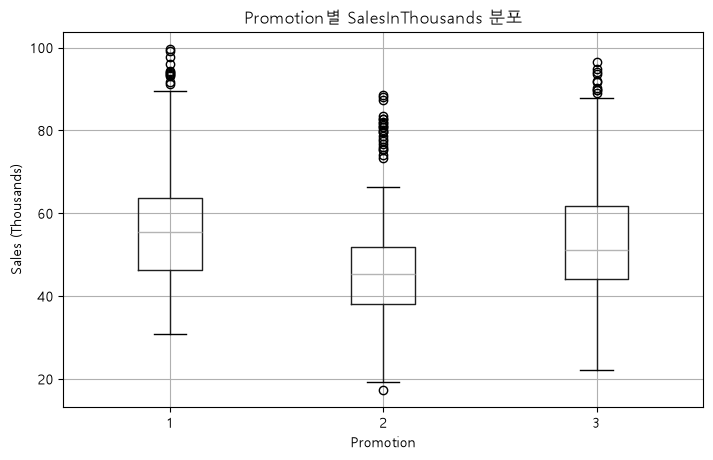

=== 그룹별 이상치 개수 ===
Promotion
1    12
2    24
3    10
Name: SalesInThousands, dtype: int64

=== 이상치 상세 (원본 행 포함) ===

Promotion 1:
     MarketID MarketSize  LocationID  AgeOfStore Promotion  week  \
83          3      Large         202           8         1     4   
108         3      Large         209           1         1     1   
109         3      Large         209           1         1     2   
110         3      Large         209           1         1     3   
111         3      Large         209           1         1     4   
114         3      Large         210          19         1     3   
128         3      Large         214           5         1     1   
130         3      Large         214           5         1     3   
144         3      Large         218           2         1     1   
154         3      Large         220           3         1     3   
160         3      Large         222           6         1     1   
163         3      Large         222           6      

In [63]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 그룹별 박스플롯
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='SalesInThousands', by='Promotion', ax=ax)
plt.title('Promotion별 SalesInThousands 분포')
plt.suptitle('')
plt.ylabel('Sales (Thousands)')
plt.show()

# IQR 기준 이상치 탐지 (그룹별)
def get_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group < lower) | (group > upper)]

print("=== 그룹별 이상치 개수 ===")
outlier_counts = df.groupby('Promotion')['SalesInThousands'].apply(lambda x: len(get_outliers_iqr(x)))
print(outlier_counts)

print("\n=== 이상치 상세 (원본 행 포함) ===")
for promo in df['Promotion'].cat.categories:
    sub = df[df['Promotion'] == promo]
    outliers = get_outliers_iqr(sub['SalesInThousands'])
    if len(outliers) > 0:
        print(f"\nPromotion {promo}:")
        print(df.loc[outliers.index])

In [64]:
# 507번 매장의 4주치 매출 다 보기
print(df[df['LocationID'] == 507])

# 같은 MarketID(6) 안의 다른 매장들과 비교
print(df[df['MarketID'] == 6].groupby('LocationID')['SalesInThousands'].mean())

     MarketID MarketSize  LocationID  AgeOfStore Promotion  week  \
284         6     Medium         507           5         2     1   
285         6     Medium         507           5         2     2   
286         6     Medium         507           5         2     3   
287         6     Medium         507           5         2     4   

     SalesInThousands  
284             38.65  
285             17.34  
286             33.14  
287             23.44  
LocationID
501    33.9125
502    32.8175
503    35.7850
504    43.3225
505    38.3400
506    31.0050
507    28.1425
508    32.3300
509    40.3150
510    29.4875
511    43.1925
512    37.8175
513    42.1900
514    39.6800
515    37.6250
Name: SalesInThousands, dtype: float64


Promotion          1          2          3
week                                      
1          58.244419  47.730213  55.776170
2          56.929535  47.582553  55.949149
3          58.774884  47.722128  54.377872
4          58.447209  46.282766  55.354681


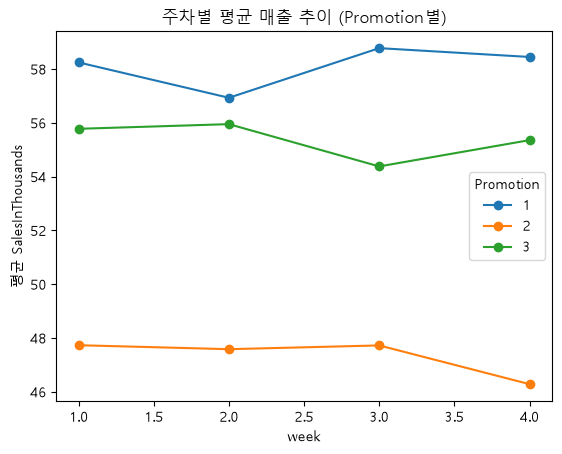


week 효과 검정: F=0.028, p=0.9935


In [65]:
import matplotlib.pyplot as plt

# 주차별 평균 매출 추이 (전체, Promotion별)
week_trend = df.groupby(['Promotion', 'week'], observed=True)['SalesInThousands'].mean().unstack(level=0)
print(week_trend)

week_trend.plot(marker='o')
plt.title('주차별 평균 매출 추이 (Promotion별)')
plt.xlabel('week')
plt.ylabel('평균 SalesInThousands')
plt.show()

# 통계적으로: week가 매출에 유의한 영향을 주는지 (One-way ANOVA, week 기준)
from scipy.stats import f_oneway
groups = [df[df['week']==w]['SalesInThousands'] for w in sorted(df['week'].unique())]
f_stat, p_val = f_oneway(*groups)
print(f"\nweek 효과 검정: F={f_stat:.3f}, p={p_val:.4f}")

In [66]:
# 매장 내(주차 간) 표준편차
within_store_std = df.groupby('LocationID')['SalesInThousands'].std().mean()
print(f"평균 매장 내(주차 간) 표준편차: {within_store_std:.2f}")

# 매장 간 표준편차 (매장별 평균들의 표준편차)
between_store_std = df.groupby('LocationID')['SalesInThousands'].mean().std()
print(f"매장 간 표준편차: {between_store_std:.2f}")

평균 매장 내(주차 간) 표준편차: 4.73
매장 간 표준편차: 16.19


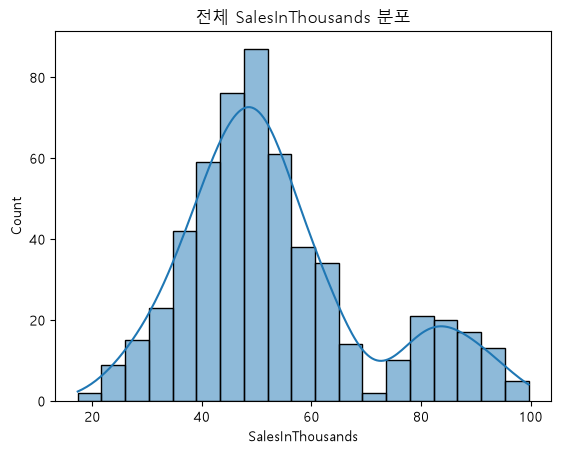

In [67]:
import seaborn as sns
sns.histplot(df['SalesInThousands'], kde=True)
plt.title('전체 SalesInThousands 분포')
plt.show()

In [68]:
store_level = df.groupby(['LocationID', 'Promotion', 'MarketID', 'MarketSize', 'AgeOfStore'], observed=True)['SalesInThousands'].mean().reset_index()
print(store_level.shape)
print(store_level.head())

(137, 6)
   LocationID Promotion  MarketID MarketSize  AgeOfStore  SalesInThousands
0           1         3         1     Medium           4           34.4200
1           2         2         1     Medium           5           29.5450
2           3         1         1     Medium          12           40.6800
3           4         2         1     Medium           1           33.7075
4           5         2         1     Medium          10           29.0025


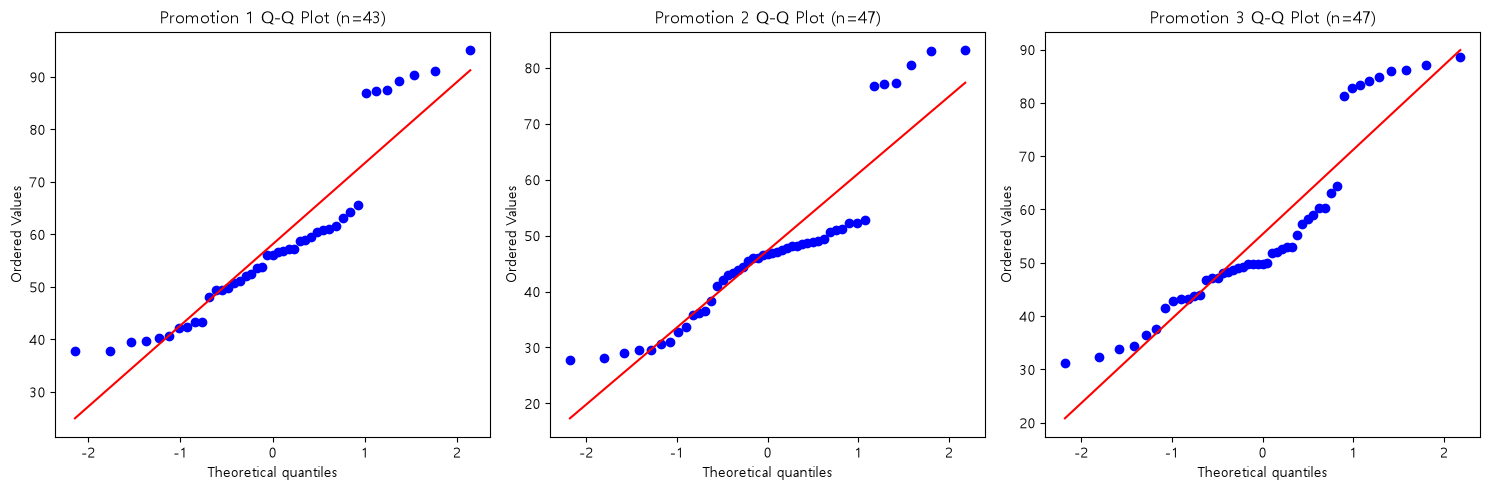

In [69]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# 매장 단위 집계 데이터 준비 (아직 안 하셨다면)
store_level = df.groupby(['LocationID', 'Promotion', 'MarketID', 'MarketSize', 'AgeOfStore'], observed=True)['SalesInThousands'].mean().reset_index()

# ===== 1. Q-Q Plot (그룹별로 시각 확인) =====
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, promo in enumerate(sorted(store_level['Promotion'].unique())):
    data = store_level[store_level['Promotion'] == promo]['SalesInThousands']
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f'Promotion {promo} Q-Q Plot (n={len(data)})')

plt.tight_layout()
plt.show()

In [70]:
print("=== Shapiro-Wilk 정규성 검정 (그룹별) ===")
for promo in sorted(store_level['Promotion'].unique()):
    data = store_level[store_level['Promotion'] == promo]['SalesInThousands']
    stat, p = stats.shapiro(data)
    print(f"Promotion {promo}: W={stat:.4f}, p={p:.4f}")

=== Shapiro-Wilk 정규성 검정 (그룹별) ===
Promotion 1: W=0.8684, p=0.0002
Promotion 2: W=0.8487, p=0.0000
Promotion 3: W=0.8760, p=0.0001


In [71]:
from scipy.stats import levene, f_oneway, kruskal

g1 = store_level[store_level['Promotion']==1]['SalesInThousands']
g2 = store_level[store_level['Promotion']==2]['SalesInThousands']
g3 = store_level[store_level['Promotion']==3]['SalesInThousands']

# 등분산 검정 (Levene)
stat, p = levene(g1, g2, g3)
print(f"Levene 검정: stat={stat:.4f}, p={p:.4f}")

# ANOVA
f_stat, p_anova = f_oneway(g1, g2, g3)
print(f"\nOne-way ANOVA: F={f_stat:.4f}, p={p_anova:.4f}")

# Kruskal-Wallis (비모수 대안, 교차검증용)
h_stat, p_kw = kruskal(g1, g2, g3)
print(f"Kruskal-Wallis: H={h_stat:.4f}, p={p_kw:.4f}")

Levene 검정: stat=0.4682, p=0.6272

One-way ANOVA: F=5.8458, p=0.0037
Kruskal-Wallis: H=17.3274, p=0.0002


In [72]:
# 자유도 확인
from scipy.stats import chi2

df_kw = 3 - 1  # 그룹 수 - 1
alpha = 0.05

critical_value = chi2.ppf(1 - alpha, df_kw)
print(f"자유도 {df_kw}, α=0.05일 때 임계값: {critical_value:.4f}")

자유도 2, α=0.05일 때 임계값: 5.9915


In [73]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=store_level['SalesInThousands'],
    groups=store_level['Promotion'],
    alpha=0.05
)
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696  0.004 -18.5951  -2.944   True
     1      3  -2.7345 0.6862 -10.5601   5.091  False
     2      3   8.0351 0.0371   0.3854 15.6847   True
-----------------------------------------------------


In [74]:
import numpy as np

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.std(ddof=1)**2 + (ny-1)*y.std(ddof=1)**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

g1 = store_level[store_level['Promotion']==1]['SalesInThousands']
g2 = store_level[store_level['Promotion']==2]['SalesInThousands']
g3 = store_level[store_level['Promotion']==3]['SalesInThousands']

print(f"Promotion 1 vs 2: Cohen's d = {cohens_d(g1, g2):.3f}")
print(f"Promotion 1 vs 3: Cohen's d = {cohens_d(g1, g3):.3f}")
print(f"Promotion 2 vs 3: Cohen's d = {cohens_d(g2, g3):.3f}")

Promotion 1 vs 2: Cohen's d = 0.706
Promotion 1 vs 3: Cohen's d = 0.169
Promotion 2 vs 3: Cohen's d = -0.519


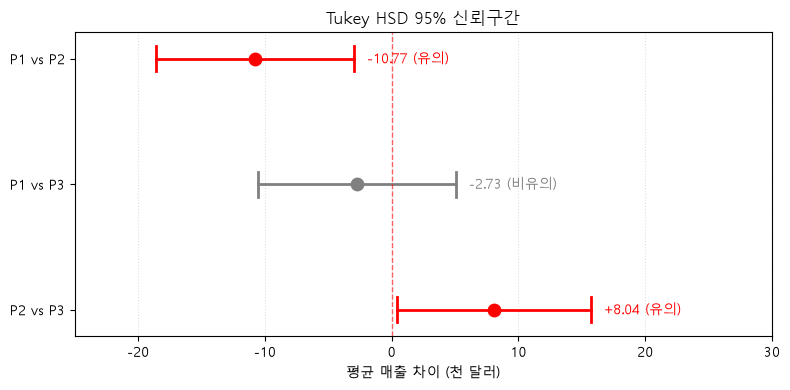

In [75]:
# 신뢰구간 시각화 확인
import matplotlib.pyplot as plt


# Tukey HSD 결과 정리 (group1, group2, meandiff, lower, upper, reject)
comparisons = [
    ("P1 vs P2", -10.7696, -18.5951, -2.944, True),
    ("P1 vs P3", -2.7345, -10.5601, 5.091, False),
    ("P2 vs P3", 8.0351, 0.3854, 15.6847, True),
]

fig, ax = plt.subplots(figsize=(8, 4))

for i, (label, mean, lower, upper, reject) in enumerate(comparisons):
    color = 'red' if reject else 'gray'
    # 신뢰구간 선
    ax.plot([lower, upper], [i, i], color=color, linewidth=2)
    # 양끝 caps
    ax.plot([lower, lower], [i-0.1, i+0.1], color=color, linewidth=2)
    ax.plot([upper, upper], [i-0.1, i+0.1], color=color, linewidth=2)
    # 평균 차이 점
    ax.scatter(mean, i, color=color, s=80, zorder=3)
    # 값 라벨
    sig_text = "유의" if reject else "비유의"
    ax.text(upper + 1, i, f"{mean:+.2f} ({sig_text})", va='center', fontsize=10, color=color)

# 0 기준선
ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)

ax.set_yticks(range(len(comparisons)))
ax.set_yticklabels([c[0] for c in comparisons])
ax.set_xlabel("평균 매출 차이 (천 달러)")
ax.set_title("Tukey HSD 95% 신뢰구간")
ax.set_xlim(-25, 30)
ax.invert_yaxis()  # 위에서부터 순서대로
ax.grid(axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('tukey_hsd_ci.png', dpi=150)
plt.show()

In [76]:
import scipy.stats as stats

g1 = store_level[store_level['Promotion']==1]['SalesInThousands']
g2 = store_level[store_level['Promotion']==2]['SalesInThousands']
g3 = store_level[store_level['Promotion']==3]['SalesInThousands']

f_stat, p_val = stats.f_oneway(g1, g2, g3)

# eta squared 계산
all_data = store_level['SalesInThousands']
grand_mean = all_data.mean()

ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in [g1, g2, g3])
ss_total = sum((all_data - grand_mean)**2)

eta_squared = ss_between / ss_total
print(f"η² = {eta_squared:.4f}")

η² = 0.0802


In [77]:
# 507번 매장의 이상치 주차(2주차, 17.34)만 제외하고 다시 집계
df_sensitivity = df[~((df['LocationID']==507) & (df['week']==2))]

store_level_sens = df_sensitivity.groupby(['LocationID','Promotion'], observed=True)['SalesInThousands'].mean().reset_index()

g1s = store_level_sens[store_level_sens['Promotion']==1]['SalesInThousands']
g2s = store_level_sens[store_level_sens['Promotion']==2]['SalesInThousands']
g3s = store_level_sens[store_level_sens['Promotion']==3]['SalesInThousands']

f_stat, p_val = stats.f_oneway(g1s, g2s, g3s)
print(f"이상치 제외 후 ANOVA: F={f_stat:.4f}, p={p_val:.4f}")

# 원본과 비교
print(f"원본 ANOVA: F=5.8458, p=0.0037")

이상치 제외 후 ANOVA: F=5.7780, p=0.0039
원본 ANOVA: F=5.8458, p=0.0037


In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Promotion × MarketSize 배정이 균등한지 =====
print("=== Promotion x MarketSize 매장 수 ===")
cross_size = pd.crosstab(store_level['Promotion'], store_level['MarketSize'])
print(cross_size)

print("\n=== 비율(행 기준, %) ===")
print((pd.crosstab(store_level['Promotion'], store_level['MarketSize'], normalize='index') * 100).round(1))

# 카이제곱 독립성 검정: Promotion과 MarketSize가 서로 독립인지
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(cross_size)
print(f"\nPromotion-MarketSize 독립성 검정: chi2={chi2:.4f}, p={p:.4f}")

# ===== 2. Promotion별 AgeOfStore(매장 연차) 평균 비교 =====
print("\n=== Promotion별 AgeOfStore 평균 ===")
print(store_level.groupby('Promotion', observed=True)['AgeOfStore'].mean())

from scipy.stats import f_oneway
age1 = store_level[store_level['Promotion']==1]['AgeOfStore']
age2 = store_level[store_level['Promotion']==2]['AgeOfStore']
age3 = store_level[store_level['Promotion']==3]['AgeOfStore']
f_age, p_age = f_oneway(age1, age2, age3)
print(f"AgeOfStore 그룹간 차이 검정: F={f_age:.4f}, p={p_age:.4f}")

# ===== 3. MarketSize를 통제한 상태에서 Promotion 효과 재확인 (이원 분산분석) =====
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('SalesInThousands ~ C(Promotion) + C(MarketSize)', data=store_level).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n=== 이원 ANOVA (Promotion + MarketSize 통제) ===")
print(anova_table)

=== Promotion x MarketSize 매장 수 ===
MarketSize  Large  Medium  Small
Promotion                       
1              14      24      5
2              16      27      4
3              12      29      6

=== 비율(행 기준, %) ===
MarketSize  Large  Medium  Small
Promotion                       
1            32.6    55.8   11.6
2            34.0    57.4    8.5
3            25.5    61.7   12.8

Promotion-MarketSize 독립성 검정: chi2=1.1885, p=0.8800

=== Promotion별 AgeOfStore 평균 ===
Promotion
1    8.279070
2    7.978723
3    9.234043
Name: AgeOfStore, dtype: float64
AgeOfStore 그룹간 차이 검정: F=0.4499, p=0.6387

=== 이원 ANOVA (Promotion + MarketSize 통제) ===
                     sum_sq     df          F        PR(>F)
C(Promotion)    3244.817690    2.0  16.036196  5.828218e-07
C(MarketSize)  19450.760385    2.0  96.127499  1.735237e-26
Residual       13354.661294  132.0        NaN           NaN


In [79]:
import scipy.stats as stats
import pandas as pd

results = []

for size in ['Small', 'Medium', 'Large']:
    subset = store_level[store_level['MarketSize'] == size]
    g1 = subset[subset['Promotion']==1]['SalesInThousands']
    g2 = subset[subset['Promotion']==2]['SalesInThousands']
    g3 = subset[subset['Promotion']==3]['SalesInThousands']
    
    f_stat, p_val = stats.f_oneway(g1, g2, g3)
    results.append({'MarketSize': size, 'n': len(subset), 'F': f_stat, 'p_raw': p_val})
    print(f"{size} (n={len(subset)}): F={f_stat:.4f}, p={p_val:.4f}")

results_df = pd.DataFrame(results)
print(results_df)

Small (n=15): F=9.6436, p=0.0032
Medium (n=80): F=10.3532, p=0.0001
Large (n=42): F=5.5224, p=0.0077
  MarketSize   n          F     p_raw
0      Small  15   9.643573  0.003183
1     Medium  80  10.353195  0.000104
2      Large  42   5.522361  0.007732


In [80]:
from statsmodels.stats.multitest import multipletests

# Bonferroni 보정
reject_bonf, p_bonf, _, _ = multipletests(results_df['p_raw'], alpha=0.05, method='bonferroni')

# BH(Benjamini-Hochberg) 보정
reject_bh, p_bh, _, _ = multipletests(results_df['p_raw'], alpha=0.05, method='fdr_bh')

results_df['p_bonferroni'] = p_bonf
results_df['reject_bonferroni'] = reject_bonf
results_df['p_BH'] = p_bh
results_df['reject_BH'] = reject_bh

print(results_df)

  MarketSize   n          F     p_raw  p_bonferroni  reject_bonferroni  \
0      Small  15   9.643573  0.003183      0.009550               True   
1     Medium  80  10.353195  0.000104      0.000313               True   
2      Large  42   5.522361  0.007732      0.023195               True   

       p_BH  reject_BH  
0  0.004775       True  
1  0.000313       True  
2  0.007732       True  


In [81]:
n_promo2 = len(store_level[store_level['Promotion']==2])
print(f"Promotion 2 매장 수: {n_promo2}개")

# Tukey에서 나온 meandiff 기준 (단위: 달러, 주당 평균)
weekly_loss_vs_1 = 10.7696 * n_promo2
weekly_loss_vs_3 = 8.0351 * n_promo2

print(f"\n주당 예상 손실 (Promotion 1 대비): ${weekly_loss_vs_1:.1f}")
print(f"주당 예상 손실 (Promotion 3 대비): ${weekly_loss_vs_3:.1f}")

# 4주 캠페인 전체 기준
print(f"\n4주 캠페인 전체 예상 손실 (vs P1): ${weekly_loss_vs_1*4:.1f}")
print(f"4주 캠페인 전체 예상 손실 (vs P3): ${weekly_loss_vs_3*4:.1f}")

Promotion 2 매장 수: 47개

주당 예상 손실 (Promotion 1 대비): $506.2
주당 예상 손실 (Promotion 3 대비): $377.6

4주 캠페인 전체 예상 손실 (vs P1): $2024.7
4주 캠페인 전체 예상 손실 (vs P3): $1510.6


In [82]:
for size in ['Small', 'Medium', 'Large']:
    subset = store_level[store_level['MarketSize'] == size]
    mean1 = subset[subset['Promotion']==1]['SalesInThousands'].mean()
    mean3 = subset[subset['Promotion']==3]['SalesInThousands'].mean()
    print(f"{size}: P1 평균={mean1:.2f}, P3 평균={mean3:.2f}, 차이(P3-P1)={mean3-mean1:.2f}")

Small: P1 평균=60.16, P3 평균=59.51, 차이(P3-P1)=-0.65
Medium: P1 평균=47.67, P3 평균=45.47, 차이(P3-P1)=-2.20
Large: P1 평균=75.24, P3 평균=77.20, 차이(P3-P1)=1.97
